# Pre-training Dataset Helpfulness Analysis

Comprehensive metrics comparing pre-training dataset configurations across 22 ADMET tasks.
Includes win-rates, geometric/arithmetic means, per-category breakdowns, rank stability, and Shapley-style marginal contributions.

Extracted from the main results dashboard. Run `00_results_dashboard.ipynb` first to understand the data pipeline.

In [1]:
import re
from pathlib import Path
from itertools import permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean, kendalltau

from notebook_utils import (
    ADMET_TASK_ORDER, TASK_CATEGORY, TASK_METRICS, TDC_SOTA,
    FAMILY_COLORS, FAMILY_HATCHES,
    infer_model_name, infer_model_family,
    load_results, load_tdc_top10, build_method_colors,
    normalize_scores, count_best_among_methods, get_sota,
)

# === Config ===
MODELS_TO_SHOW = [
    'gpspp_800M',
    'pairformer_17M',
    'pairmixer_10M',
]

df, admet_df = load_results(models_to_show=MODELS_TO_SHOW)
TDC_TOP10_ALL, TDC_TOP10_AVG, TDC_TOP10_MEDIAN = load_tdc_top10()
METHOD_COLORS = build_method_colors(admet_df)

print(f"Loaded {len(df)} rows, {len(admet_df)} ADMET rows")
print(f"Models: {admet_df['model_name'].value_counts().to_dict()}")
print(f"Methods: {sorted(admet_df['method'].unique())}")

Loaded 1279 rows from ../results/experiment_results.csv
After filtering to ['gpspp_800M', 'pairformer_17M', 'pairmixer_10M']: 695 rows
  model_name counts: {'gpspp_800M': 659, 'pairmixer_10M': 31, 'pairformer_17M': 5}
Tasks with extracted metrics: 627 / 695

Failed metric extraction (68 rows):
  - task='multitask' × 67 rows  (task not in TASK_METRICS (not an ADMET single-task))
  - task='pgp_broccatelli' × 1 rows  (metric value is NaN)
After dedup to latest run per (task, model_name, method): 318 rows
Models in data: {'gpspp_800M': 289, 'pairmixer_10M': 24, 'pairformer_17M': 5}
Method color assignments: {'Scratch': '#999999', 'dti': '#466eff', 'largemix': '#64B478', 'largemix_dti': '#EB423D', 'rxrx3': '#FF883D', 'rxrx3_dti': '#9B59B6', 'toymix': '#17becf', 'toymix_bbbc047': '#bcbd22', 'toymix_dti': '#e377c2', 'toymix_dti_esmc_v2': '#d62728', 'toymix_dti_filtered': '#8c564b', 'toymix_dti_v2': '#466eff', 'toymix_lpm24': '#64B478', 'toymix_rxrx3': '#EB423D', 'toymix_rxrx3_dti': '#FF883D'}

method,TDC SOTA,Scratch,dti,largemix,largemix_dti,rxrx3,rxrx3_dti,toymix,toymix_bbbc047,toymix_dti,toymix_dti_esmc_v2,toymix_dti_filtered,toymix_dti_v2,toymix_lpm24,toymix_rxrx3,toymix_rxrx3_dti
caco2_wang (mae ↓),0.256 ± 0.006,0.5648,5.3263,0.4899,0.5056,1.2462,0.7230,5.2247,0.4873,0.4466,0.4917,0.5672,0.5379,0.5891,0.5438,0.5284
hia_hou (auroc ↑),0.993 ± 0.005,0.5000,0.5000,0.9014,0.6840,0.4988,0.7267,0.8333,0.9150,0.8712,0.9465,0.9506,0.8317,0.7700,0.6066,0.7313
pgp_broccatelli (auroc ↑),0.938 ± 0.002,0.8214,0.5000,0.8890,0.8134,0.4373,0.8194,0.8155,0.7902,0.8919,0.8684,0.7996,0.7353,0.7792,0.8305,0.7345
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.5000,0.5000,0.5271,0.5316,0.5037,0.5786,0.6275,0.4613,0.5632,0.5614,0.6345,0.5735,0.6209,0.5449,0.5883
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,0.9721,2.3666,0.7559,0.8889,0.9677,0.9647,0.9724,0.8961,0.8436,0.9017,0.9145,0.9381,0.9462,0.9782,0.9174
solubility_aqsoldb (mae ↓),0.741 ± 0.013,1.0424,3.4085,1.0715,1.5022,1.8897,1.4641,1.4957,1.4241,1.2442,1.3547,1.3231,1.4160,1.4697,1.2084,1.2582
bbb_martins (auroc ↑),0.924 ± 0.003,0.7324,0.5000,0.8485,0.7972,0.5569,0.7043,0.3988,0.7403,0.8080,0.7502,0.8086,0.7837,0.7229,0.7836,0.7282
ppbr_az (mae ↓),7.440 ± 0.024,81.4208,88.6763,8.5499,9.4128,17.4642,15.7294,13.3702,9.6523,8.8819,8.9347,9.5635,9.8418,,9.6962,9.6880
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.4539,0.0000,0.4888,0.4398,0.0541,0.2888,0.2426,0.5075,0.5988,0.5919,0.5317,0.4528,,0.3875,0.4868
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.1766,0.1687,0.6463,0.4494,0.1488,0.4021,0.1469,0.4283,0.5229,,0.3949,,,0.4564,0.4094



Tasks where each method is best (gpspp_800M):
  Scratch: 2/22
  dti: 0/22
  largemix: 10/22
  largemix_dti: 0/22
  rxrx3: 0/22
  rxrx3_dti: 0/22
  toymix: 1/22
  toymix_bbbc047: 0/22
  toymix_dti: 6/22
  toymix_dti_esmc_v2: 0/22
  toymix_dti_filtered: 2/22
  toymix_dti_v2: 0/22
  toymix_lpm24: 0/22
  toymix_rxrx3: 0/22
  toymix_rxrx3_dti: 1/22

  pairformer_17M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch
caco2_wang (mae ↓),0.256 ± 0.006,1.0859
hia_hou (auroc ↑),0.993 ± 0.005,
pgp_broccatelli (auroc ↑),0.938 ± 0.002,0.8511
bioavailability_ma (auroc ↑),0.938 ± 0.002,
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,
solubility_aqsoldb (mae ↓),0.741 ± 0.013,0.9141
bbb_martins (auroc ↑),0.924 ± 0.003,
ppbr_az (mae ↓),7.440 ± 0.024,
vdss_lombardo (spearman ↑),0.713 ± 0.007,
cyp2d6_veith (auprc ↑),0.790 ± 0.001,



Tasks where each method is best (pairformer_17M):
  Scratch: 5/5

  pairmixer_10M
Bold = best within architecture | Blue + underline = best across all architectures


method,TDC SOTA,Scratch,toymix,toymix_dti
caco2_wang (mae ↓),0.256 ± 0.006,,,5.2500
hia_hou (auroc ↑),0.993 ± 0.005,,,0.5000
pgp_broccatelli (auroc ↑),0.938 ± 0.002,,,0.5000
bioavailability_ma (auroc ↑),0.938 ± 0.002,,,0.5000
lipophilicity_astrazeneca (mae ↓),0.456 ± 0.008,1.0625,0.9492,1.9922
solubility_aqsoldb (mae ↓),0.741 ± 0.013,,,2.7031
bbb_martins (auroc ↑),0.924 ± 0.003,,,0.5000
ppbr_az (mae ↓),7.440 ± 0.024,,,89.0000
vdss_lombardo (spearman ↑),0.713 ± 0.007,,,0.0000
cyp2d6_veith (auprc ↑),0.790 ± 0.001,,,0.1687



Tasks where each method is best (pairmixer_10M):
  Scratch: 0/22
  toymix: 1/22
  toymix_dti: 21/22

  Cross-architecture summary: tasks where each (model, method) is best
  gpspp_800M / Scratch: 1/22
  gpspp_800M / dti: 0/22
  gpspp_800M / largemix: 10/22
  gpspp_800M / largemix_dti: 0/22
  gpspp_800M / rxrx3: 0/22
  gpspp_800M / rxrx3_dti: 0/22
  gpspp_800M / toymix: 1/22
  gpspp_800M / toymix_bbbc047: 0/22
  gpspp_800M / toymix_dti: 6/22
  gpspp_800M / toymix_dti_esmc_v2: 0/22
  gpspp_800M / toymix_dti_filtered: 2/22
  gpspp_800M / toymix_dti_v2: 0/22
  gpspp_800M / toymix_lpm24: 0/22
  gpspp_800M / toymix_rxrx3: 0/22
  gpspp_800M / toymix_rxrx3_dti: 1/22
  pairformer_17M / Scratch: 1/22
  pairmixer_10M / Scratch: 0/22
  pairmixer_10M / toymix: 0/22
  pairmixer_10M / toymix_dti: 0/22


In [2]:
# ── 9.0  Build score pivot and normalized pivot ──────────────────────────────

EPSILON = 0.01  # floor for geomean (avoids log(0))

# Build task × method pivot from admet_df (mean across seeds)
_h = admet_df.groupby(['task', 'method'])['primary_metric'].mean().reset_index()
score_pivot = _h.pivot(index='task', columns='method', values='primary_metric')
score_pivot = score_pivot.reindex(index=[t for t in ADMET_TASK_ORDER if t in score_pivot.index])

# Normalize: flip MAE tasks (lower=better → higher=better), then min-max to [0, 1]
norm_pivot = score_pivot.copy()
for task in norm_pivot.index:
    direction = TASK_METRICS.get(task, (None, 'higher'))[1]
    row = norm_pivot.loc[task].astype(float)
    if direction == 'lower':
        row = -row
    vmin, vmax = row.min(), row.max()
    if vmax == vmin:
        norm_pivot.loc[task] = 0.5
    else:
        norm_pivot.loc[task] = (row - vmin) / (vmax - vmin)

methods = list(score_pivot.columns)
print(f"Score pivot: {score_pivot.shape[0]} tasks × {score_pivot.shape[1]} methods")
print(f"Methods: {methods}")
print()
print("Normalized scores (higher = better, 1.0 = best among methods):")
display(norm_pivot.round(3).style.background_gradient(cmap='RdYlGn', axis=1))

Score pivot: 22 tasks × 15 methods
Methods: ['Scratch', 'dti', 'largemix', 'largemix_dti', 'rxrx3', 'rxrx3_dti', 'toymix', 'toymix_bbbc047', 'toymix_dti', 'toymix_dti_esmc_v2', 'toymix_dti_filtered', 'toymix_dti_v2', 'toymix_lpm24', 'toymix_rxrx3', 'toymix_rxrx3_dti']

Normalized scores (higher = better, 1.0 = best among methods):


method,Scratch,dti,largemix,largemix_dti,rxrx3,rxrx3_dti,toymix,toymix_bbbc047,toymix_dti,toymix_dti_esmc_v2,toymix_dti_filtered,toymix_dti_v2,toymix_lpm24,toymix_rxrx3,toymix_rxrx3_dti
task,,,,,,,,,,,,,,,
caco2_wang,0.930000,0.000000,0.999000,0.996000,0.843000,0.951000,0.021000,1.000000,0.512000,0.999000,0.983000,0.990000,0.979000,0.988000,0.991000
hia_hou,0.003000,0.003000,0.891000,0.410000,0.000000,0.505000,0.740000,0.921000,0.413000,0.991000,1.000000,0.737000,0.600000,0.239000,0.515000
pgp_broccatelli,0.883000,0.139000,1.000000,0.833000,0.000000,0.846000,0.837000,0.781000,0.573000,0.955000,0.802000,0.660000,0.757000,0.871000,0.658000
bioavailability_ma,0.224000,0.224000,0.380000,0.406000,0.245000,0.678000,0.960000,0.000000,0.406000,0.578000,1.000000,0.648000,0.921000,0.483000,0.733000
lipophilicity_astrazeneca,0.838000,0.000000,1.000000,0.917000,0.869000,0.870000,0.873000,0.913000,0.589000,0.909000,0.902000,0.887000,0.882000,0.862000,0.900000
solubility_aqsoldb,1.000000,0.000000,0.962000,0.784000,0.625000,0.800000,0.787000,0.817000,0.590000,0.845000,0.858000,0.820000,0.798000,0.905000,0.885000
bbb_martins,0.742000,0.225000,1.000000,0.886000,0.352000,0.679000,0.000000,0.759000,0.568000,0.781000,0.911000,0.856000,0.721000,0.856000,0.733000
ppbr_az,0.091000,0.000000,1.000000,0.989000,0.889000,0.910000,0.940000,0.986000,0.496000,0.995000,0.987000,0.984000,nan,0.986000,0.986000
vdss_lombardo,0.767000,0.000000,0.826000,0.743000,0.091000,0.488000,0.410000,0.857000,0.506000,1.000000,0.898000,0.765000,nan,0.655000,0.823000


## 1. Win-Rate Analysis

Pairwise: for each pair (A, B), count how many of the 22 tasks A beats B (respecting metric direction).
Also shows how many tasks each method is the single best.

In [3]:
# ── 9.1  Pairwise win-rate matrix ────────────────────────────────────────────
n = len(methods)
win_matrix = pd.DataFrame(0, index=methods, columns=methods, dtype=int)

for task in score_pivot.index:
    direction = TASK_METRICS.get(task, (None, 'higher'))[1]
    vals = score_pivot.loc[task]
    for i, a in enumerate(methods):
        for j, b in enumerate(methods):
            if i == j:
                continue
            va, vb = vals[a], vals[b]
            if pd.isna(va) or pd.isna(vb):
                continue
            if direction == 'lower':
                if va < vb:
                    win_matrix.loc[a, b] += 1
            else:
                if va > vb:
                    win_matrix.loc[a, b] += 1

n_tasks = score_pivot.shape[0]
print(f"Pairwise win counts (out of {n_tasks} tasks):")
print("Read as: row A beats column B on N tasks")
print()
display(win_matrix.style.background_gradient(cmap='Blues'))

# Wins as best (single best on each task)
best_counts = count_best_among_methods(score_pivot, methods, TASK_METRICS)
print()
print("Tasks where each method is THE BEST:")
for m in methods:
    wins, total = best_counts.get(m, (0, n_tasks))
    print(f"  {m:30s}  {wins:2d}/{total}")

Pairwise win counts (out of 22 tasks):
Read as: row A beats column B on N tasks



,Scratch,dti,largemix,largemix_dti,rxrx3,rxrx3_dti,toymix,toymix_bbbc047,toymix_dti,toymix_dti_esmc_v2,toymix_dti_filtered,toymix_dti_v2,toymix_lpm24,toymix_rxrx3,toymix_rxrx3_dti
Scratch,0,15,3,6,14,8,11,7,10,1,4,3,3,8,6
dti,4,0,0,0,5,1,5,1,0,0,0,0,0,4,0
largemix,19,22,0,20,21,21,20,19,21,6,18,8,6,20,20
largemix_dti,16,22,2,0,20,16,16,13,20,2,12,5,4,14,12
rxrx3,8,17,1,2,0,4,7,4,7,0,2,0,0,5,2
rxrx3_dti,14,21,1,6,18,0,16,7,17,1,5,2,2,8,6
toymix,11,17,2,6,15,6,0,4,10,1,2,3,3,7,5
toymix_bbbc047,15,21,3,9,18,15,18,0,17,2,9,6,6,12,14
toymix_dti,12,22,1,2,15,5,12,5,0,0,1,0,0,6,3
toymix_dti_esmc_v2,8,9,3,7,9,8,8,7,9,0,5,7,6,7,7



Tasks where each method is THE BEST:
  Scratch                          2/22
  dti                              0/22
  largemix                        13/22
  largemix_dti                     1/22
  rxrx3                            0/22
  rxrx3_dti                        0/22
  toymix                           1/22
  toymix_bbbc047                   1/22
  toymix_dti                       0/22
  toymix_dti_esmc_v2               1/22
  toymix_dti_filtered              2/22
  toymix_dti_v2                    0/22
  toymix_lpm24                     0/22
  toymix_rxrx3                     0/22
  toymix_rxrx3_dti                 1/22


## 2. Normalized Score Aggregates

**Geometric mean** is the key metric — it multiplicatively penalizes catastrophic failures.
A method scoring 0.0 on any single task would drag its geomean to zero; we clip at ε=0.01.

Also reports arithmetic mean and median. Large |mean − median| gap signals outlier tasks.

In [4]:
# ── 9.2  Geometric mean, arithmetic mean, median ─────────────────────────────
agg_rows = []
for m in methods:
    scores = norm_pivot[m].dropna().values.astype(float)
    clipped = np.clip(scores, EPSILON, None)
    geo = gmean(clipped)
    arith = np.mean(scores)
    med = np.median(scores)
    std = np.std(scores)
    worst_idx = np.argmin(scores)
    worst_task = norm_pivot.index[worst_idx]
    worst_raw = score_pivot.loc[worst_task, m]
    agg_rows.append({
        'method': m,
        'geomean': geo,
        'mean': arith,
        'median': med,
        'std': std,
        'min_norm': scores.min(),
        'worst_task': worst_task,
        'worst_raw': worst_raw,
        'mean_med_gap': abs(arith - med),
    })

agg_table = pd.DataFrame(agg_rows).set_index('method').sort_values('geomean', ascending=False)

print("Aggregate normalized scores (sorted by geometric mean, higher = better):")
print(f"  ε = {EPSILON} (floor for geomean computation)")
print()

# Highlight rows where mean-median gap > 0.1
def _highlight_gap(row):
    styles = [''] * len(row)
    if row['mean_med_gap'] > 0.1:
        styles[row.index.get_loc('mean_med_gap')] = 'background-color: #ffcccc'
    return styles

display(agg_table[['geomean', 'mean', 'median', 'std', 'min_norm', 'worst_task', 'worst_raw', 'mean_med_gap']]
        .style
        .format({'geomean': '{:.4f}', 'mean': '{:.4f}', 'median': '{:.4f}',
                 'std': '{:.4f}', 'min_norm': '{:.3f}', 'worst_raw': '{:.4f}',
                 'mean_med_gap': '{:.3f}'})
        .apply(_highlight_gap, axis=1)
        .bar(subset=['geomean'], color='#5fba7d'))

Aggregate normalized scores (sorted by geometric mean, higher = better):
  ε = 0.01 (floor for geomean computation)



,geomean,mean,median,std,min_norm,worst_task,worst_raw,mean_med_gap
method,,,,,,,,
largemix,0.9201,0.9363,1.0000,0.1410,0.380,bioavailability_ma,0.5271,0.064
toymix_dti_esmc_v2,0.8830,0.8948,0.9546,0.1337,0.578,bioavailability_ma,0.5614,0.060
toymix_dti_v2,0.8075,0.8162,0.8199,0.1186,0.648,bioavailability_ma,0.5735,0.004
toymix_lpm24,0.7989,0.8083,0.7978,0.1201,0.600,hia_hou,0.7700,0.010
toymix_dti_filtered,0.7440,0.7795,0.8781,0.2084,0.277,cyp2c9_substrate_carbonmangels,0.3241,0.099
largemix_dti,0.6905,0.7191,0.7565,0.1946,0.406,bioavailability_ma,0.5316,0.037
toymix_rxrx3_dti,0.6568,0.6963,0.7207,0.2224,0.302,cyp2c9_substrate_carbonmangels,0.3284,0.024
toymix_bbbc047,0.5302,0.6766,0.7505,0.2655,0.000,bioavailability_ma,0.4613,0.074
rxrx3_dti,0.5126,0.6402,0.6785,0.2584,0.000,clearance_hepatocyte_az,-0.1069,0.038


## 3. Win Magnitude Analysis

For each method vs a baseline (Scratch), split tasks into wins and losses.
Reports average normalized-score delta on each side.
"Wins big, loses small" is better than "wins small, loses big".

Win/loss magnitude vs Scratch (normalized scores, higher = better):


,n_wins,avg_win_delta,n_losses,avg_loss_delta,n_ties,net_delta
method,,,,,,
largemix,19,+0.5666,3,-0.0294,0,+0.4853
toymix_dti_filtered,18,+0.4298,4,-0.1273,0,+0.3285
toymix_dti_esmc_v2,8,+0.3415,1,-0.1549,0,+0.2863
largemix_dti,16,+0.4002,6,-0.0844,0,+0.2681
toymix_rxrx3_dti,16,+0.3932,6,-0.1492,0,+0.2453
toymix_bbbc047,15,+0.3991,7,-0.1462,0,+0.2256
toymix_dti_v2,6,+0.3790,3,-0.1351,0,+0.2077
rxrx3_dti,14,+0.3716,8,-0.1301,0,+0.1892
toymix_rxrx3,14,+0.3295,8,-0.1673,0,+0.1489


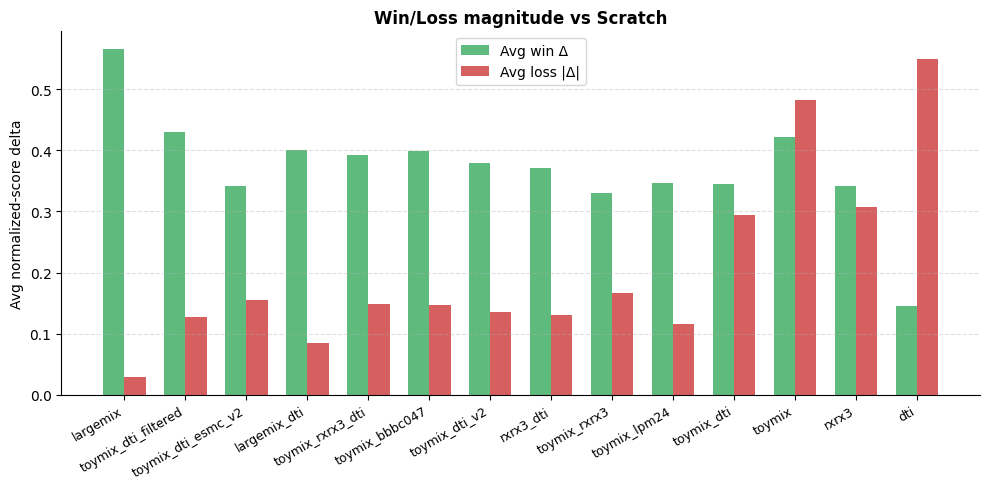

In [5]:
# ── 9.3  Win magnitude vs baseline ───────────────────────────────────────────
BASELINE = 'Scratch'

mag_rows = []
for m in methods:
    if m == BASELINE:
        continue
    deltas = norm_pivot[m] - norm_pivot[BASELINE]
    wins = deltas[deltas > 0]
    losses = deltas[deltas < 0]
    ties = deltas[deltas == 0]
    mag_rows.append({
        'method': m,
        'n_wins': len(wins),
        'avg_win_delta': wins.mean() if len(wins) > 0 else 0.0,
        'n_losses': len(losses),
        'avg_loss_delta': losses.mean() if len(losses) > 0 else 0.0,
        'n_ties': len(ties),
        'net_delta': deltas.mean(),
    })

mag_df = pd.DataFrame(mag_rows).set_index('method').sort_values('net_delta', ascending=False)
print(f"Win/loss magnitude vs {BASELINE} (normalized scores, higher = better):")
display(mag_df.style.format({
    'avg_win_delta': '{:+.4f}', 'avg_loss_delta': '{:+.4f}', 'net_delta': '{:+.4f}',
}).bar(subset=['net_delta'], color=['#d65f5f', '#5fba7d'], align='zero'))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(mag_df))
w = 0.35
ax.bar(x - w/2, mag_df['avg_win_delta'], w, label='Avg win Δ', color='#5fba7d')
ax.bar(x + w/2, mag_df['avg_loss_delta'].abs(), w, label='Avg loss |Δ|', color='#d65f5f')
ax.set_xticks(x)
ax.set_xticklabels(mag_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Avg normalized-score delta')
ax.set_title(f'Win/Loss magnitude vs {BASELINE}', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Per-Category Breakdown

All metrics (geomean, mean, median, wins) computed per ADMET category.
This is critical — a pre-training dataset that helps Metabolism may hurt Toxicity.

In [6]:
# ── 9.4  Per-category breakdown ──────────────────────────────────────────────
CATEGORIES = ['Absorption', 'Distribution', 'Metabolism', 'Excretion', 'Toxicity']
cat_rows = []

for cat in CATEGORIES:
    cat_tasks = [t for t in norm_pivot.index if TASK_CATEGORY.get(t) == cat]
    if not cat_tasks:
        continue
    cat_norm = norm_pivot.loc[cat_tasks]
    cat_score = score_pivot.loc[cat_tasks]

    for m in methods:
        scores = cat_norm[m].dropna().values.astype(float)
        if len(scores) == 0:
            continue
        clipped = np.clip(scores, EPSILON, None)

        # Count wins (best on task within this category)
        n_best = 0
        for t in cat_tasks:
            direction = TASK_METRICS.get(t, (None, 'higher'))[1]
            row = cat_score.loc[t].dropna()
            if len(row) == 0:
                continue
            best = row.idxmin() if direction == 'lower' else row.idxmax()
            if best == m:
                n_best += 1

        cat_rows.append({
            'category': cat,
            'method': m,
            'geomean': gmean(clipped),
            'mean': np.mean(scores),
            'median': np.median(scores),
            'wins': n_best,
            'n_tasks': len(cat_tasks),
        })

cat_df = pd.DataFrame(cat_rows)
cat_pivot = cat_df.pivot(index='category', columns='method', values='geomean')
cat_pivot = cat_pivot.reindex(index=CATEGORIES)

print("Geometric mean of normalized scores per category:")
display(cat_pivot.round(4).style.background_gradient(cmap='RdYlGn', axis=1))

# Full breakdown table
print()
print("Full per-category breakdown:")
for cat in CATEGORIES:
    sub = cat_df[cat_df['category'] == cat].set_index('method').sort_values('geomean', ascending=False)
    print(f"\n── {cat} ({sub['n_tasks'].iloc[0]} tasks) ──")
    display(sub[['geomean', 'mean', 'median', 'wins']].style.format(
        {'geomean': '{:.4f}', 'mean': '{:.4f}', 'median': '{:.4f}'}
    ).bar(subset=['geomean'], color='#5fba7d'))

Geometric mean of normalized scores per category:


method,Scratch,dti,largemix,largemix_dti,rxrx3,rxrx3_dti,toymix,toymix_bbbc047,toymix_dti,toymix_dti_esmc_v2,toymix_dti_filtered,toymix_dti_v2,toymix_lpm24,toymix_rxrx3,toymix_rxrx3_dti
category,,,,,,,,,,,,,,,
Absorption,0.339800,0.026000,0.829400,0.680500,0.149600,0.759300,0.452500,0.418400,0.507700,0.865300,0.921000,0.780800,0.812800,0.652700,0.762100
Distribution,0.372100,0.028200,0.938200,0.866800,0.305600,0.670800,0.156800,0.862700,0.522200,0.919600,0.931500,0.863700,0.720700,0.820500,0.840600
Metabolism,0.090000,0.035800,0.945300,0.647000,0.061100,0.528600,0.109600,0.374000,0.444600,nan,0.589900,nan,nan,0.445800,0.561700
Excretion,0.073900,0.170700,1.000000,0.582200,0.146500,0.105000,0.184300,0.698500,0.495100,nan,0.621300,nan,nan,0.022300,0.452200
Toxicity,0.280000,0.053100,0.955900,0.745700,0.402400,0.728900,0.088200,0.720800,0.519200,nan,0.740200,nan,nan,0.809100,0.730700



Full per-category breakdown:

── Absorption (6 tasks) ──


,geomean,mean,median,wins
method,,,,
toymix_dti_filtered,0.9210,0.9242,0.9425,2
toymix_dti_esmc_v2,0.8653,0.8795,0.9320,0
largemix,0.8294,0.8720,0.9805,2
toymix_lpm24,0.8128,0.8229,0.8398,0
toymix_dti_v2,0.7808,0.7901,0.7783,0
toymix_rxrx3_dti,0.7621,0.7803,0.8090,0
rxrx3_dti,0.7593,0.7750,0.8231,0
largemix_dti,0.6805,0.7244,0.8086,0
toymix_rxrx3,0.6527,0.7246,0.8663,0



── Distribution (3 tasks) ──


...

,geomean,mean,median,wins
method,,,,
largemix,0.9453,0.9513,1.0000,4
largemix_dti,0.6470,0.6695,0.6293,1
toymix_dti_filtered,0.5899,0.6325,0.6407,0
toymix_rxrx3_dti,0.5617,0.5957,0.5558,0
rxrx3_dti,0.5286,0.5900,0.5919,0
toymix_rxrx3,0.4458,0.4908,0.4822,0
toymix_dti,0.4446,0.4683,0.3925,0
toymix_bbbc047,0.3740,0.4661,0.4964,0
toymix,0.1096,0.3232,0.2468,1



── Excretion (3 tasks) ──


,geomean,mean,median,wins
method,,,,
largemix,1.0000,1.0000,1.0000,3
toymix_bbbc047,0.6985,0.7083,0.7676,0
toymix_dti_filtered,0.6213,0.6442,0.5390,0
largemix_dti,0.5822,0.6028,0.5821,0
toymix_dti,0.4951,0.5057,0.4395,0
toymix_rxrx3_dti,0.4522,0.4542,0.4538,0
toymix,0.1843,0.2515,0.1389,0
dti,0.1707,0.1955,0.2022,0
rxrx3,0.1465,0.2193,0.2696,0



── Toxicity (4 tasks) ──


,geomean,mean,median,wins
method,,,,
largemix,0.9559,0.9582,0.9941,2
toymix_rxrx3,0.8091,0.8244,0.8746,0
largemix_dti,0.7457,0.7573,0.7186,0
toymix_dti_filtered,0.7402,0.7698,0.8318,0
toymix_rxrx3_dti,0.7307,0.7895,0.9037,1
rxrx3_dti,0.7289,0.7550,0.8007,0
toymix_bbbc047,0.7208,0.7321,0.6667,0
toymix_dti,0.5192,0.5344,0.5678,0
rxrx3,0.4024,0.5094,0.4542,0


## 5. Rank Stability (Kendall's τ)

For each pair of tasks, rank all methods and compute Kendall's τ.
High average τ → methods rank consistently across tasks → a single "best" config exists.
Low τ → rankings are task-dependent → no universal winner.

Overall average pairwise Kendall's τ = 0.3516
  (1.0 = perfect agreement, 0.0 = no correlation, <0 = inversely correlated)

  Absorption       τ = 0.2877  (6 tasks)
  Distribution     τ = 0.5604  (3 tasks)
  Metabolism       τ = 0.3535  (6 tasks)
  Excretion        τ = 0.5992  (3 tasks)
  Toxicity         τ = 0.3232  (4 tasks)


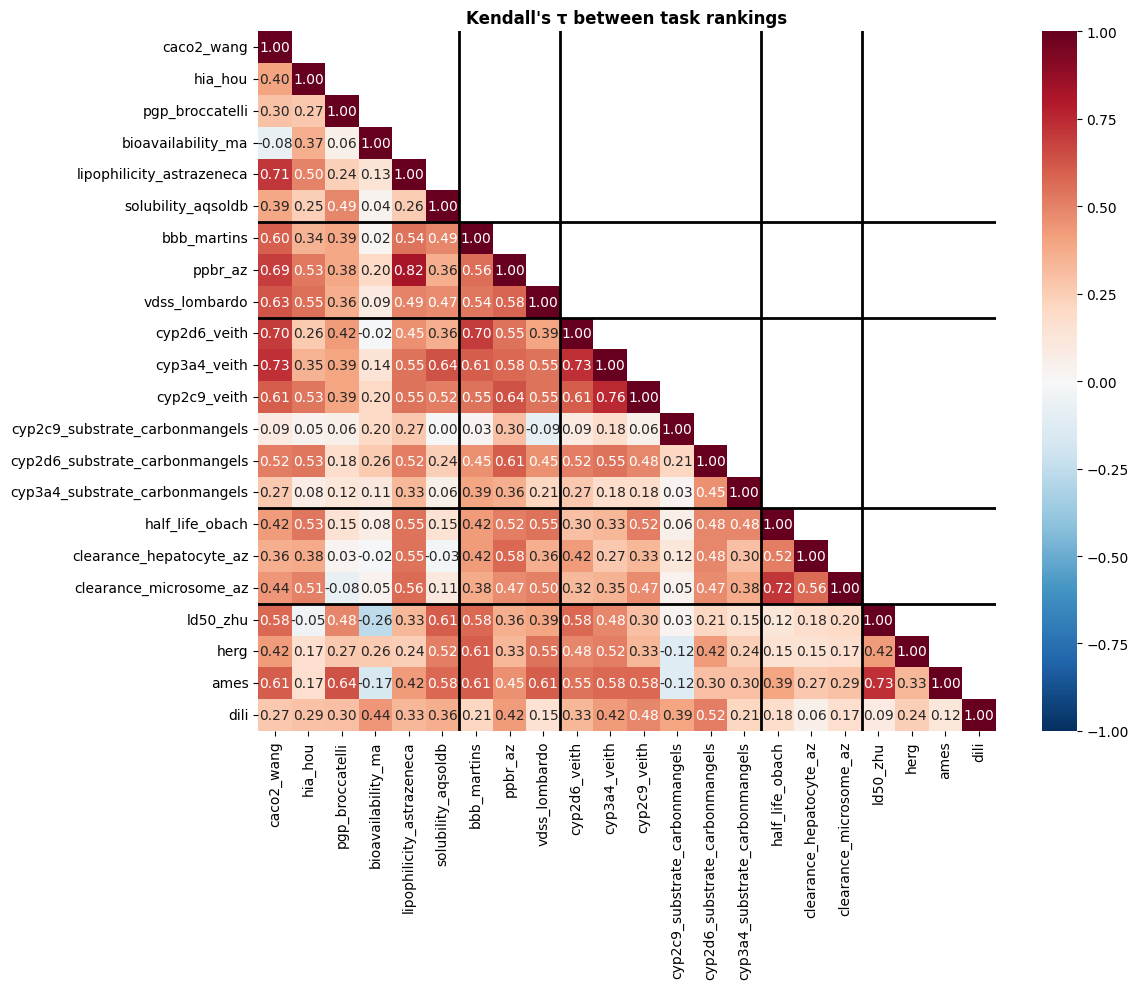

In [7]:
# ── 9.5  Rank stability (Kendall's tau) ──────────────────────────────────────
tasks_list = list(norm_pivot.index)
n_t = len(tasks_list)
tau_matrix = pd.DataFrame(np.nan, index=tasks_list, columns=tasks_list)

for i in range(n_t):
    for j in range(i, n_t):
        t1, t2 = tasks_list[i], tasks_list[j]
        r1 = norm_pivot.loc[t1].rank()
        r2 = norm_pivot.loc[t2].rank()
        valid = r1.notna() & r2.notna()
        if valid.sum() < 3:
            continue
        tau, _ = kendalltau(r1[valid], r2[valid])
        tau_matrix.loc[t1, t2] = tau
        tau_matrix.loc[t2, t1] = tau

# Overall average tau (upper triangle only)
taus = []
for i in range(n_t):
    for j in range(i+1, n_t):
        v = tau_matrix.iloc[i, j]
        if not np.isnan(v):
            taus.append(v)
avg_tau = np.mean(taus) if taus else float('nan')
print(f"Overall average pairwise Kendall's τ = {avg_tau:.4f}")
print(f"  (1.0 = perfect agreement, 0.0 = no correlation, <0 = inversely correlated)")
print()

# Per-category average tau
for cat in CATEGORIES:
    cat_tasks = [t for t in tasks_list if TASK_CATEGORY.get(t) == cat]
    cat_taus = []
    for i, t1 in enumerate(cat_tasks):
        for j, t2 in enumerate(cat_tasks):
            if i < j:
                v = tau_matrix.loc[t1, t2]
                if not np.isnan(v):
                    cat_taus.append(v)
    cat_avg = np.mean(cat_taus) if cat_taus else float('nan')
    print(f"  {cat:15s}  τ = {cat_avg:.4f}  ({len(cat_tasks)} tasks)")

# Heatmap of tau matrix
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(tau_matrix, dtype=bool), k=1)
sns.heatmap(tau_matrix.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title("Kendall's τ between task rankings", fontweight='bold')

# Add category separators
cat_boundaries = []
idx = 0
for cat in CATEGORIES:
    cat_tasks = [t for t in tasks_list if TASK_CATEGORY.get(t) == cat]
    idx += len(cat_tasks)
    cat_boundaries.append(idx)
for b in cat_boundaries[:-1]:
    ax.axhline(y=b, color='black', linewidth=2)
    ax.axvline(x=b, color='black', linewidth=2)

plt.tight_layout()
plt.show()

## 6. Marginal Contribution (Shapley Values)

Decompose the contribution of each auxiliary modality (DTI, RxRx3) beyond the base (ToyMix).
Shapley value = average marginal contribution across all orderings in which the modality could be added.

Available data points: Scratch, toymix, dti, rxrx3, rxrx3_dti, toymix_dti, toymix_rxrx3.

In [8]:
# ── 9.6  Shapley-style marginal contributions ────────────────────────────────
# Map method labels to modality sets.
# Method names come from build_method_label() → pretrain_type (raw names, not "FT (...)")
METHOD_MODALITIES = {
    'Scratch':           set(),
    'dti':               {'dti'},
    'rxrx3':             {'rxrx3'},
    'toymix':            {'toymix'},
    'rxrx3_dti':         {'rxrx3', 'dti'},
    'toymix_dti':        {'toymix', 'dti'},
    'toymix_rxrx3':      {'toymix', 'rxrx3'},
    'toymix_rxrx3_dti':  {'toymix', 'rxrx3', 'dti'},
    'largemix_dti':      {'largemix', 'dti'},
    'toymix_dti_v2':     {'toymix', 'dti_v2'},
    'toymix_dti_esmc_v2': {'toymix', 'dti_esmc_v2'},
    'toymix_lpm24':      {'toymix', 'lpm24'},
}

# Method label lookup from modality set
MODALITY_TO_METHOD = {frozenset(v): k for k, v in METHOD_MODALITIES.items()
                      if k in agg_table.index}

# All modalities (we have all 2^3 = 8 subsets for these 3)
ALL_MODALITIES = ['toymix', 'dti', 'rxrx3']

# Get geomean for a method (from agg_table computed in 9.2)
def get_geomean(method_name):
    if method_name and method_name in agg_table.index:
        return agg_table.loc[method_name, 'geomean']
    return None

# Compute Shapley values: average marginal contribution across all orderings
shapley = {m: [] for m in ALL_MODALITIES}

for perm in permutations(ALL_MODALITIES):
    current_set = set()
    prev_val = get_geomean(MODALITY_TO_METHOD.get(frozenset(current_set)))
    for modality in perm:
        new_set = current_set | {modality}
        method_key = frozenset(new_set)
        method_name = MODALITY_TO_METHOD.get(method_key)
        curr_val = get_geomean(method_name)
        if prev_val is not None and curr_val is not None:
            shapley[modality].append(curr_val - prev_val)
        current_set = new_set
        prev_val = curr_val

print("Shapley-style marginal contributions (geomean of normalized scores):")
print("  Positive = adding this modality improves average performance")
print("  Negative = adding this modality hurts average performance")
print()
shapley_df_rows = []
for m in ALL_MODALITIES:
    vals = shapley[m]
    if vals:
        shapley_df_rows.append({
            'modality': m,
            'shapley_value': np.mean(vals),
            'std': np.std(vals),
            'n_orderings': len(vals),
            'min_marginal': np.min(vals),
            'max_marginal': np.max(vals),
        })
    else:
        shapley_df_rows.append({
            'modality': m,
            'shapley_value': float('nan'),
            'std': float('nan'),
            'n_orderings': 0,
            'min_marginal': float('nan'),
            'max_marginal': float('nan'),
        })

shapley_df = pd.DataFrame(shapley_df_rows).set_index('modality')
display(shapley_df.style.format({
    'shapley_value': '{:+.4f}', 'std': '{:.4f}',
    'min_marginal': '{:+.4f}', 'max_marginal': '{:+.4f}',
}).bar(subset=['shapley_value'], color=['#d65f5f', '#5fba7d'], align='zero'))

# Modality stacking table: show score at each combination
print()
print("Modality stacking (geomean at each combination):")
stacking_rows = []
for method, mods in sorted(METHOD_MODALITIES.items(), key=lambda x: len(x[1])):
    gm = get_geomean(method)
    if gm is not None:
        stacking_rows.append({
            'method': method,
            'modalities': '+'.join(sorted(mods)) if mods else '(none)',
            'n_modalities': len(mods),
            'geomean': gm,
        })
stacking_df = pd.DataFrame(stacking_rows).sort_values(['n_modalities', 'geomean'])
display(stacking_df.set_index('method').style.format({'geomean': '{:.4f}'})
        .bar(subset=['geomean'], color='#5fba7d'))

Shapley-style marginal contributions (geomean of normalized scores):
  Positive = adding this modality improves average performance
  Negative = adding this modality hurts average performance



,shapley_value,std,n_orderings,min_marginal,max_marginal
modality,,,,,
toymix,+0.1593,0.1588,6,-0.0129,+0.4496
dti,+0.1503,0.2120,6,-0.1455,+0.3584
rxrx3,+0.1594,0.1709,6,-0.0335,+0.4704



Modality stacking (geomean at each combination):


,modalities,n_modalities,geomean
method,,,
Scratch,(none),0,0.1877
dti,dti,1,0.0422
rxrx3,rxrx3,1,0.1542
toymix,toymix,1,0.1748
toymix_rxrx3,rxrx3+toymix,2,0.3981
toymix_dti,dti+toymix,2,0.4918
rxrx3_dti,dti+rxrx3,2,0.5126
largemix_dti,dti+largemix,2,0.6905
toymix_lpm24,lpm24+toymix,2,0.7989


## 7. Heatmap: Normalized Scores (methods × tasks)

Tasks grouped by ADMET category. Annotated with raw metric values, colored by normalized score.

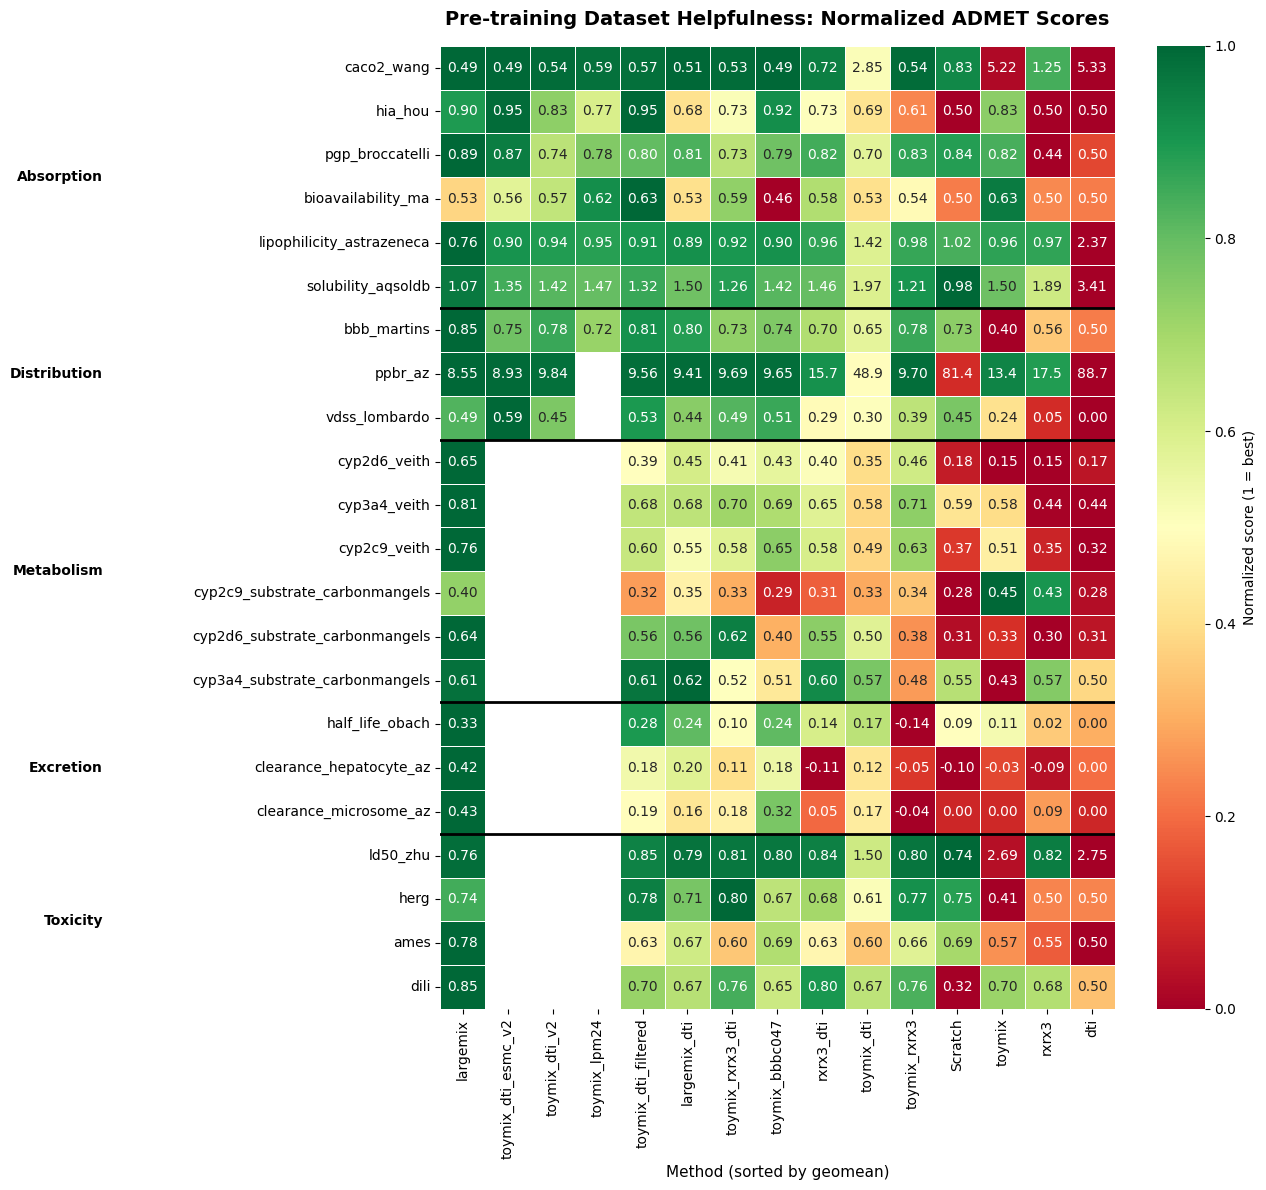

In [9]:
# ── 9.7  Heatmap of normalized scores ────────────────────────────────────────
# Order methods by geomean (best on left)
method_order = agg_table.index.tolist()
plot_norm = norm_pivot[method_order].copy()

# Annotation: raw score values (compact format)
annot = score_pivot[method_order].copy()
for col in annot.columns:
    annot[col] = annot[col].apply(lambda v: f'{v:.2f}' if abs(v) < 10 else f'{v:.1f}')

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(plot_norm.astype(float), annot=annot, fmt='',
            cmap='RdYlGn', vmin=0, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalized score (1 = best)'})
ax.set_title('Pre-training Dataset Helpfulness: Normalized ADMET Scores',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Method (sorted by geomean)', fontsize=11)
ax.set_ylabel('')

# Add category separators and labels
y = 0
for cat in CATEGORIES:
    cat_tasks = [t for t in plot_norm.index if TASK_CATEGORY.get(t) == cat]
    if not cat_tasks:
        continue
    mid = y + len(cat_tasks) / 2
    ax.text(-0.5, mid, cat, ha='right', va='center', fontsize=10,
            fontweight='bold', rotation=0, transform=ax.get_yaxis_transform())
    y += len(cat_tasks)
    if y < len(plot_norm):
        ax.axhline(y=y, color='black', linewidth=2)

plt.tight_layout()
plt.show()

## 8. Export Results

In [10]:
# ── 9.8  Export all helpfulness metrics to XLSX ──────────────────────────────
XLSX_PATH = Path('../results/helpfulness_metrics.xlsx')

with pd.ExcelWriter(XLSX_PATH, engine='openpyxl') as writer:
    # Overall metrics
    agg_table.to_excel(writer, sheet_name='overall_metrics')

    # Per-category breakdown
    cat_df.to_excel(writer, sheet_name='per_category', index=False)

    # Pairwise win matrix
    win_matrix.to_excel(writer, sheet_name='pairwise_wins')

    # Marginal contributions
    shapley_df.to_excel(writer, sheet_name='marginal_contributions')

    # Rank stability
    tau_matrix.to_excel(writer, sheet_name='rank_stability')

    # Normalized scores
    norm_pivot.to_excel(writer, sheet_name='normalized_scores')

    # Raw scores
    score_pivot.to_excel(writer, sheet_name='raw_scores')

    # Win magnitude
    mag_df.to_excel(writer, sheet_name='win_magnitude')

print(f"Saved helpfulness metrics to {XLSX_PATH.resolve()}")
sheets = ['overall_metrics', 'per_category', 'pairwise_wins',
         'marginal_contributions', 'rank_stability',
         'normalized_scores', 'raw_scores', 'win_magnitude']
print(f"Sheets: {sheets}")

Saved helpfulness metrics to /home/shpark/prj-molrepr/graphium/results/helpfulness_metrics.xlsx
Sheets: ['overall_metrics', 'per_category', 'pairwise_wins', 'marginal_contributions', 'rank_stability', 'normalized_scores', 'raw_scores', 'win_magnitude']
